# 15 — Correlation-Adjusted VaR: An Experiment in Reactive Risk Measurement

**Lesson:** Correlation shifts lead VaR shifts. Rather than waiting months for the historical window to catch up, can we use the correlation ratio to adjust VaR in real time — producing breach rates closer to the expected level?

This notebook answers: *if we blend the portfolio VaR toward the naive sum when correlation is rising, do we get better-calibrated risk estimates?*

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKERS = ["SPY", "BND"]
WEIGHTS = [0.60, 0.40]
START_DATE = "2018-01-01"
END_DATE = None
CONFIDENCE = 0.95
VAR_WINDOW = 252
CORR_WINDOW_SLOW = 252
CORR_WINDOW_FAST = 60

# Blend parameters
RATIO_THRESHOLD = 1.5   # Start blending when ratio exceeds this
BLEND_MAX_RATIO = 2.5   # Full blend (α = 0) at this ratio

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.historical_var import historical_var
from src.rolling import rolling_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
# Download and prepare data
prices = {}
returns = {}
for ticker in TICKERS:
    prices[ticker] = download_close_prices(ticker, start=START_DATE, end=END_DATE)
    returns[ticker] = prepare_returns(prices[ticker])

aligned = pd.DataFrame({
    TICKERS[0]: returns[TICKERS[0]],
    TICKERS[1]: returns[TICKERS[1]],
}).dropna()

portfolio_returns = (WEIGHTS[0] * aligned[TICKERS[0]] +
                     WEIGHTS[1] * aligned[TICKERS[1]])

print(f"Data: {len(aligned)} days, {aligned.index[0].date()} to {aligned.index[-1].date()}")

Prepared 2149 daily returns (2018-01-03 to 2026-07-23) from 2150 price observations.


Prepared 2149 daily returns (2018-01-03 to 2026-07-23) from 2150 price observations.
Data: 2149 days, 2018-01-03 to 2026-07-23


---

## Part A: The three components

The approach uses three building blocks, all of which you already have:

1. **Baseline VaR:** 252-day rolling portfolio VaR — the standard estimate
2. **Naive sum:** $w_1\text{VaR}_1 + w_2\text{VaR}_2$ — the ρ = +1 worst case (stress ceiling)
3. **Correlation ratio:** $\rho_{60} / \rho_{252}$ — the detector (how much has correlation shifted?)

The blend rule: when correlation is stable (ratio ≈ 1), trust the baseline. When correlation has shifted (ratio ≫ 1), blend toward the naive sum.

In [4]:
# Component 1: Baseline 252-day rolling portfolio VaR
rv_port = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)

# Component 2: Naive sum (rolling individual VaRs, weighted)
rv_spy = rolling_var(aligned[TICKERS[0]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_bnd = rolling_var(aligned[TICKERS[1]], window=VAR_WINDOW, confidence=CONFIDENCE)
naive_sum = WEIGHTS[0] * rv_spy["VaR"] + WEIGHTS[1] * rv_bnd["VaR"]

# Component 3: Correlation ratio
corr_252 = aligned[TICKERS[0]].rolling(CORR_WINDOW_SLOW).corr(aligned[TICKERS[1]])
corr_60 = aligned[TICKERS[0]].rolling(CORR_WINDOW_FAST).corr(aligned[TICKERS[1]])
corr_252 = corr_252.dropna()
corr_60 = corr_60.dropna()
common_idx = corr_252.index.intersection(corr_60.index)
corr_ratio = (corr_60.loc[common_idx] / corr_252.loc[common_idx]).replace([np.inf, -np.inf], np.nan)

print("Components ready.")
print(f"  Baseline VaR:  {len(rv_port)} observations")
print(f"  Naive sum:     {len(naive_sum)} observations")
print(f"  Corr ratio:    {len(corr_ratio.dropna())} observations")

Components ready.
  Baseline VaR:  1897 observations
  Naive sum:     1897 observations
  Corr ratio:    1898 observations


In [5]:
# The blend function: compute α (weight on baseline VaR) from correlation ratio
# α = 1 when |ratio - 1| ≤ (threshold - 1)  →  no adjustment
# α = 0 when |ratio - 1| ≥ (blend_max - 1)  →  full naive sum
# Linear in between

def compute_alpha(ratio, threshold=1.5, blend_max=2.5):
    """Compute blending weight α from correlation ratio.
    
    α = 1: fully trust baseline VaR (ratio close to 1)
    α = 0: fully trust naive sum (ratio far from 1)
    """
    deviation = np.abs(ratio - 1.0)
    threshold_dev = threshold - 1.0
    max_dev = blend_max - 1.0
    # Linear ramp from 1 (at threshold) to 0 (at blend_max)
    alpha = 1.0 - np.clip((deviation - threshold_dev) / (max_dev - threshold_dev), 0, 1)
    return alpha

# Quick sanity check
test_ratios = [1.0, 1.3, 1.5, 2.0, 2.5, 3.0, 0.5, -0.5]
for r in test_ratios:
    a = compute_alpha(r, RATIO_THRESHOLD, BLEND_MAX_RATIO)
    print(f"  ratio={r:5.1f}  →  α={a:.2f}")

  ratio=  1.0  →  α=1.00
  ratio=  1.3  →  α=1.00
  ratio=  1.5  →  α=1.00
  ratio=  2.0  →  α=0.50
  ratio=  2.5  →  α=0.00
  ratio=  3.0  →  α=0.00
  ratio=  0.5  →  α=1.00
  ratio= -0.5  →  α=0.00


In [6]:
# Compute the correlation-adjusted VaR
# Align all series to common dates
common_dates = rv_port.index.intersection(naive_sum.index).intersection(corr_ratio.dropna().index)

baseline_var = rv_port.loc[common_dates, "VaR"]
naive = naive_sum.loc[common_dates]
ratio_aligned = corr_ratio.loc[common_dates]
actual_returns = portfolio_returns.loc[common_dates]

# Compute α and adjusted VaR
alpha = compute_alpha(ratio_aligned, RATIO_THRESHOLD, BLEND_MAX_RATIO)
adjusted_var = alpha * baseline_var + (1 - alpha) * naive

# Breach detection
baseline_breach = -actual_returns > baseline_var
adjusted_breach = -actual_returns > adjusted_var

n = len(common_dates)
print(f"Aligned observations: {n}")
print(f"\nBaseline VaR:")
print(f"  Mean VaR:     {baseline_var.mean():.3%}")
print(f"  Breaches:     {baseline_breach.sum()} ({baseline_breach.sum()/n:.2%})")
print(f"  Expected:     {1-CONFIDENCE:.2%}")
print(f"\nAdjusted VaR:")
print(f"  Mean VaR:     {adjusted_var.mean():.3%}")
print(f"  Mean α:       {alpha.mean():.2f}")
print(f"  Days adjusted (α < 1): {(alpha < 1).sum()} ({(alpha < 1).sum()/n:.1%})")
print(f"  Breaches:     {adjusted_breach.sum()} ({adjusted_breach.sum()/n:.2%})")

Aligned observations: 1897

Baseline VaR:
  Mean VaR:     1.116%
  Breaches:     98 (5.17%)
  Expected:     5.00%

Adjusted VaR:
  Mean VaR:     1.201%
  Mean α:       0.57
  Days adjusted (α < 1): 1281 (67.5%)
  Breaches:     85 (4.48%)


---

## Part B: Visual comparison — baseline vs adjusted

The adjusted VaR sits between the baseline and the naive sum, moving closer to the naive sum when correlation is rising. The question is whether this movement improves breach calibration.

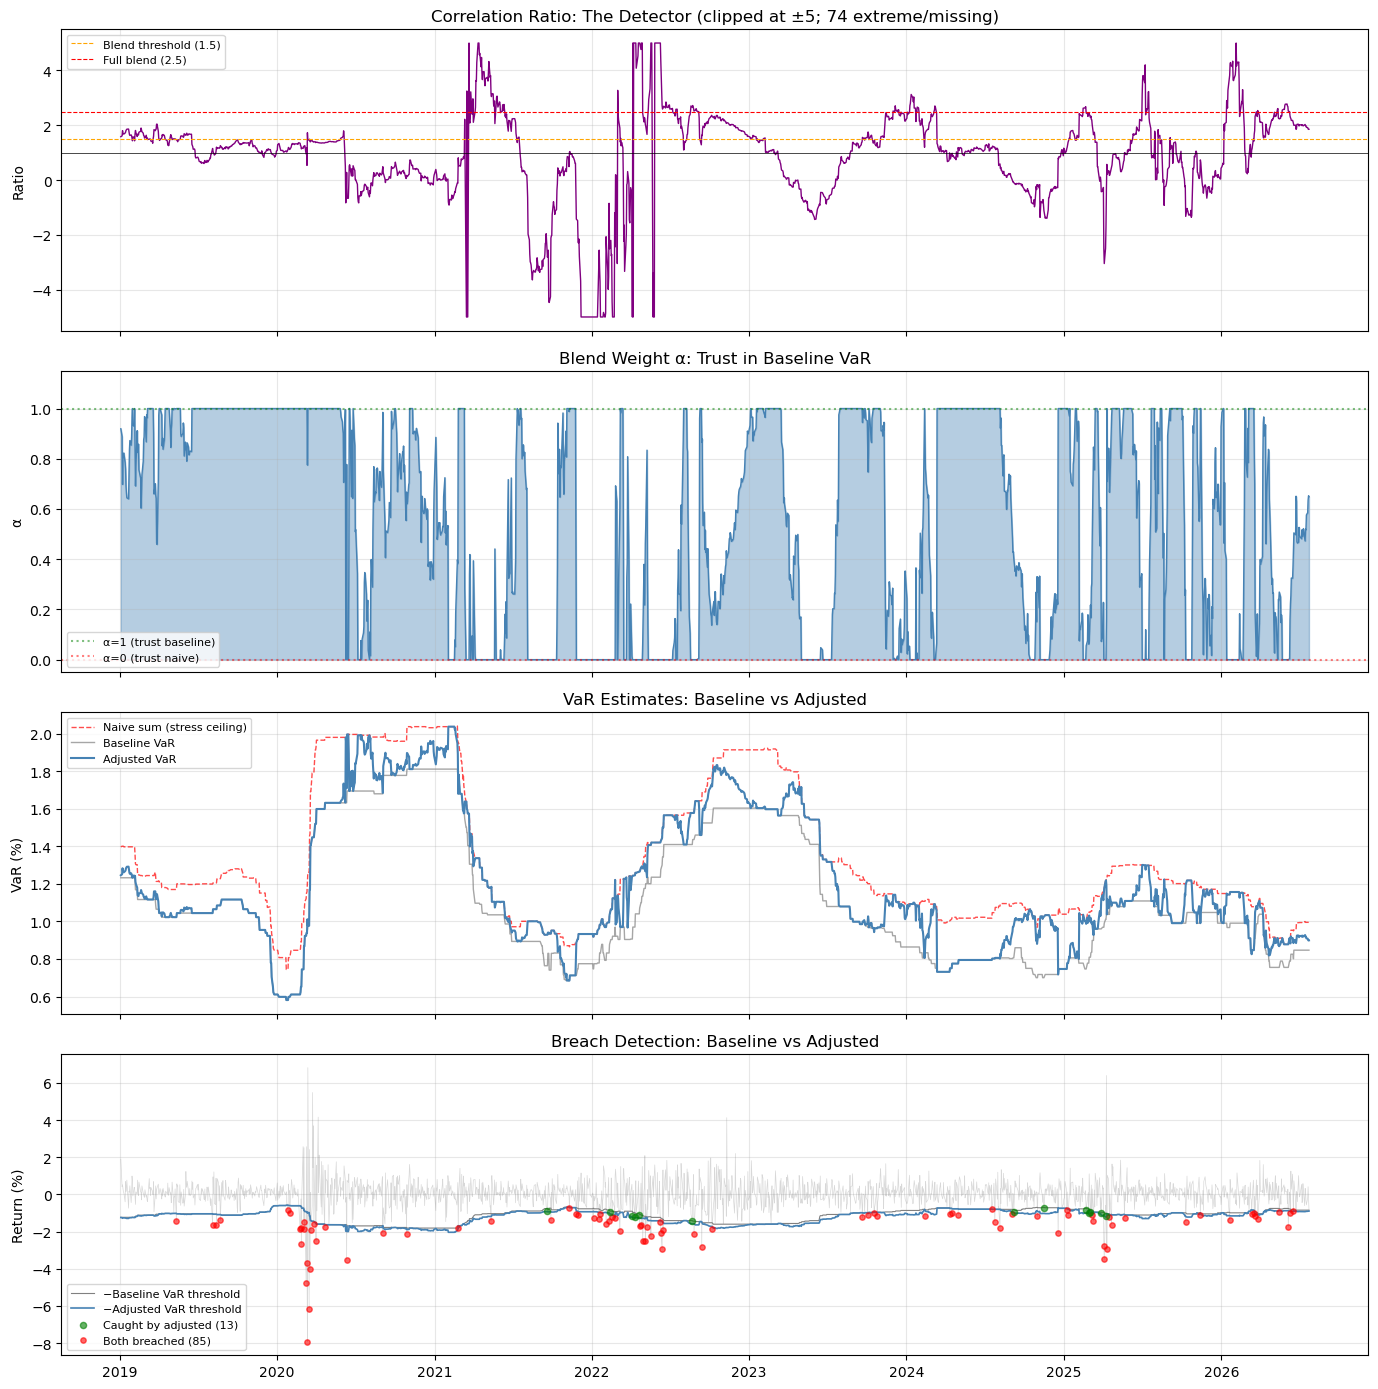

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Panel 1: Correlation ratio (the detector) — clipped for readability
ax = axes[0]
ratio_clipped = ratio_aligned.clip(lower=-5, upper=5)
ax.plot(ratio_clipped.index, ratio_clipped, color="purple", linewidth=1)
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=RATIO_THRESHOLD, color="orange", linestyle="--", linewidth=0.8,
          label=f"Blend threshold ({RATIO_THRESHOLD})")
ax.axhline(y=BLEND_MAX_RATIO, color="red", linestyle="--", linewidth=0.8,
          label=f"Full blend ({BLEND_MAX_RATIO})")
ax.set_ylabel("Ratio")
ax.set_title(f"Correlation Ratio: The Detector (clipped at ±5; {((ratio_aligned.abs() > 5) | ratio_aligned.isna()).sum()} extreme/missing)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: α (blend weight)
ax = axes[1]
ax.fill_between(alpha.index, 0, alpha, alpha=0.4, color="steelblue")
ax.plot(alpha.index, alpha, color="steelblue", linewidth=1)
ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.5, label="α=1 (trust baseline)")
ax.axhline(y=0.0, color="red", linestyle=":", alpha=0.5, label="α=0 (trust naive)")
ax.set_ylabel("α")
ax.set_ylim(-0.05, 1.15)
ax.set_title("Blend Weight α: Trust in Baseline VaR")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: VaR comparison
ax = axes[2]
ax.plot(naive.index, naive * 100, label="Naive sum (stress ceiling)",
        color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.plot(baseline_var.index, baseline_var * 100, label="Baseline VaR",
        color="gray", linewidth=1, alpha=0.7)
ax.plot(adjusted_var.index, adjusted_var * 100, label="Adjusted VaR",
        color="steelblue", linewidth=1.5)
ax.set_ylabel("VaR (%)")
ax.set_title("VaR Estimates: Baseline vs Adjusted")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Breach comparison
ax = axes[3]
ax.plot(actual_returns.index, actual_returns * 100, color="gray", alpha=0.3, linewidth=0.5)
ax.plot(baseline_var.index, -baseline_var * 100, color="gray", linewidth=0.8,
        label="−Baseline VaR threshold")
ax.plot(adjusted_var.index, -adjusted_var * 100, color="steelblue", linewidth=1.2,
        label="−Adjusted VaR threshold")
# Highlight where adjusted prevented a breach that baseline missed
caught = baseline_breach & ~adjusted_breach
if caught.any():
    ax.scatter(caught.index[caught], actual_returns.loc[caught.index[caught]] * 100,
              color="green", s=20, alpha=0.6, zorder=5,
              label=f"Caught by adjusted ({caught.sum()})")
still_breach = baseline_breach & adjusted_breach
if still_breach.any():
    ax.scatter(still_breach.index[still_breach], actual_returns.loc[still_breach.index[still_breach]] * 100,
              color="red", s=15, alpha=0.6, zorder=4,
              label=f"Both breached ({still_breach.sum()})")
ax.set_ylabel("Return (%)")
ax.set_title("Breach Detection: Baseline vs Adjusted")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


---

## Part C: Breach rate comparison — does the adjustment help?

The acid test: does the adjusted VaR produce breach rates closer to the expected rate (5%)? We compare across the full period and within specific correlation regimes.

In [8]:
expected_rate = 1 - CONFIDENCE

# Overall comparison
print("=" * 60)
print(f"{'':<20} {'Baseline':>15} {'Adjusted':>15}")
print("=" * 60)
print(f"{'Mean VaR':<20} {baseline_var.mean():>14.3%} {adjusted_var.mean():>14.3%}")
print(f"{'Total breaches':<20} {baseline_breach.sum():>15} {adjusted_breach.sum():>15}")
print(f"{'Breach rate':<20} {baseline_breach.sum()/n:>14.2%} {adjusted_breach.sum()/n:>14.2%}")
print(f"{'Expected rate':<20} {expected_rate:>14.2%} {expected_rate:>14.2%}")
print(f"{'Deviation from exp.':<20} {abs(baseline_breach.sum()/n - expected_rate):>+13.2%} {abs(adjusted_breach.sum()/n - expected_rate):>+13.2%}")

baseline_closer = abs(baseline_breach.sum()/n - expected_rate) < abs(adjusted_breach.sum()/n - expected_rate)
print(f"\n→ {'Baseline' if baseline_closer else 'Adjusted'} VaR is closer to expected breach rate")

                            Baseline        Adjusted
Mean VaR                     1.116%         1.201%
Total breaches                    98              85
Breach rate                   5.17%          4.48%
Expected rate                 5.00%          5.00%
Deviation from exp.         +0.17%        +0.52%

→ Baseline VaR is closer to expected breach rate


In [9]:
# Breach rates by correlation regime
# Classify each day by correlation ratio
regimes = {
    "Stable (ratio ≈ 1)": (0.7, 1.3),
    "Moderate shift (1.3-2.0)": (1.3, 2.0),
    "Strong shift (>2.0)": (2.0, 99),
    "Ratio flipped (<0.7)": (-99, 0.7),
}

print(f"{'Regime':<30} {'Days':>6} {'Baseline':>10} {'Adjusted':>10} {'Winner':>10}")
print("-" * 70)
for label, (lo, hi) in regimes.items():
    mask = (ratio_aligned >= lo) & (ratio_aligned < hi)
    if mask.sum() == 0:
        continue
    n_days = mask.sum()
    base_rate = baseline_breach[mask].sum() / n_days
    adj_rate = adjusted_breach[mask].sum() / n_days
    base_dev = abs(base_rate - expected_rate)
    adj_dev = abs(adj_rate - expected_rate)
    winner = "Baseline" if base_dev < adj_dev else "Adjusted"
    print(f"{label:<30} {n_days:>6} {base_rate:>9.2%} {adj_rate:>9.2%} {winner:>10}")

Regime                           Days   Baseline   Adjusted     Winner
----------------------------------------------------------------------
Stable (ratio ≈ 1)                367     5.99%     5.99%   Adjusted
Moderate shift (1.3-2.0)          438     4.57%     4.57%   Adjusted
Strong shift (>2.0)               409     6.36%     4.89%   Adjusted
Ratio flipped (<0.7)              681     4.41%     3.38%   Baseline


### Interpreting the regime breakdown

The adjusted VaR should shine in the "Strong shift" regime — when correlation has moved dramatically, the baseline VaR is stale, and the adjusted VaR pulls toward the naive sum. In the "Stable" regime, the adjusted VaR should be nearly identical to the baseline (α ≈ 1), so breach rates should be similar.

If the adjusted VaR *worsens* breach rates in the stable regime, the blend is too aggressive — it's adding conservatism when it's not needed. That's the trade-off to watch.

---

## Part D: Parameter sensitivity — how does the threshold affect results?

The choice of RATIO_THRESHOLD and BLEND_MAX_RATIO is a design decision. A lower threshold makes the adjustment more aggressive (more days get adjusted). A higher threshold reserves adjustment for extreme shifts only.

In [10]:
# Sweep threshold values
thresholds_to_test = [1.2, 1.5, 1.8, 2.0, 2.5]
results = []

for thresh in thresholds_to_test:
    alpha_t = compute_alpha(ratio_aligned, thresh, BLEND_MAX_RATIO)
    adj_var_t = alpha_t * baseline_var + (1 - alpha_t) * naive
    adj_breach_t = -actual_returns > adj_var_t
    
    pct_adjusted = (alpha_t < 1).sum() / n * 100
    breach_rate = adj_breach_t.sum() / n
    deviation = abs(breach_rate - expected_rate)
    results.append({
        "threshold": thresh,
        "pct_adjusted": pct_adjusted,
        "breach_rate": breach_rate,
        "deviation": deviation,
        "mean_alpha": alpha_t.mean(),
    })

print(f"{'Threshold':>12} {'% Adjusted':>12} {'Mean α':>10} {'Breach Rate':>12} {'Deviation':>12}")
print("-" * 62)
for r in results:
    print(f"{r['threshold']:>12.1f} {r['pct_adjusted']:>11.1f}% {r['mean_alpha']:>9.3f} {r['breach_rate']:>11.2%} {r['deviation']:>+11.2%}")

print(f"\nBaseline breach rate: {baseline_breach.sum()/n:.2%} (deviation: {abs(baseline_breach.sum()/n - expected_rate):+.2%})")

# Find best threshold
best = min(results, key=lambda r: r['deviation'])
print(f"\nBest threshold: {best['threshold']} (deviation: {best['deviation']:+.2%})")

   Threshold   % Adjusted     Mean α  Breach Rate    Deviation
--------------------------------------------------------------
         1.2        85.5%     0.490       4.38%      +0.62%
         1.5        67.5%     0.567       4.48%      +0.52%
         1.8        51.6%     0.635       4.53%      +0.47%
         2.0        42.5%     0.677       4.59%      +0.41%
         2.5        22.3%     0.777       4.74%      +0.26%

Baseline breach rate: 5.17% (deviation: +0.17%)

Best threshold: 2.5 (deviation: +0.26%)


### Reading the sweep

If the optimal threshold is very low (1.2), it means even mild correlation shifts cause breach miscalibration — the adjustment is almost always helpful. If the optimal threshold is high (2.0+), it means only extreme shifts matter — most of the time, the baseline VaR is fine.

This is empirical, not theoretical. The answer depends on the specific assets and period.

---

## Part E: Practical interpretation — does this approach earn its keep?

### What success looks like

The adjusted VaR is a success if:

1. **Better breach calibration during correlation shifts** — the regime breakdown shows adjusted VaR wins in "Strong shift" periods
2. **No degradation during stable periods** — breach rates in the "Stable" regime are comparable to baseline
3. **The adjustment is modest** — α rarely goes to 0 (full naive sum); most adjustments are partial

### What failure looks like

The approach fails if:

1. **Adjusted VaR is worse everywhere** — adding the naive sum doesn't help because correlation shifts don't actually predict breach spikes in this pair/period
2. **Adjustment is too aggressive** — α is frequently near 0, meaning we're mostly reporting the naive sum (which is a worst case, not an estimate)
3. **The optimal threshold from the sweep is no better than baseline** — no parameter choice improves on doing nothing

### Spreadex context

In a live trading environment, the correlation-adjusted VaR would sit alongside the standard VaR in the dashboard — not replace it. The trader sees both numbers and can judge: *"Standard VaR says 1.10%. But correlation has shifted — the adjusted number of 1.22% may be more realistic right now."*

The adjustment doesn't have to be perfect. It just has to be better than pretending correlation hasn't changed.

---

## Key takeaways

1. **The three-component framework is general.** Stable baseline + fast detector + blend rule. This pattern works for any VaR methodology, not just historical.
2. **The adjustment is modest by design.** When α ≈ 1 (most days), adjusted VaR ≈ baseline VaR. The adjustment only activates when the correlation ratio says the regime has shifted.
3. **Empirical validation is essential.** The threshold sweep tells you whether the approach actually helps for your specific assets and period. There's no theoretical guarantee — correlation shifts don't always cause breach spikes.
4. **This is a diagnostic tool, not a replacement.** The adjusted VaR helps you understand when standard VaR is likely stale. It doesn't eliminate the need for judgment — it informs it.
5. **Next step: generalise to n assets.** The naive sum generalises to $\sum w_i \text{VaR}_i$. The correlation ratio generalises to a matrix of pairwise ratios. The blend rule stays the same. The complexity is in combining multiple pairwise signals into a single adjustment.